# RQ-D15 — v3 코퍼스 재현 (D 자기 반증)

| 항목 | 값 |
|---|---|
| research_question | 코퍼스 결함 2건(D-DEF-01 인코딩 · D-DEF-04 CSS 오염)을 고친 v3 에서 NLP 계열 실험의 **판정**이 살아남는가 |
| hypothesis_id | `H-D15-CORPUS-ROBUSTNESS` |
| competing | H-D15-ROBUST / H-D15-FRAGILE / H-D15-NUMERIC_ONLY |
| corpus v1 sha256 | `00420e0b68e4a762bd524040594268deae41bf4e8fac2d887c6b2b3d252c5ad8` |
| corpus v2 sha256 | `bf6bb772faa45541c780c75f5cbffa856783a34661a84e3de27a9eb5da4ea36a` |
| corpus v3 sha256 | `b944bc37153c50a69dc4464ac899884f1ad4db2b77fb719267cc6de0dcd64719` |
| code sha256 | `390db903fd6cb46f82b9b5ad4be6c03b412c3591cf3b8002399bd5e6cb2167df` |
| result json sha256 | `a776b1415a9880f940e2d0bb37736ed94b77fcb7c2e3e275bc25f785403688e9` |
| MLflow run_id | `229a338130744d4cb6016e2b5933505b` (experiment `LA_03_RF_MAPPING`) |
| n | 56 target (in_mart==1), expected 56 |
| grain | target state — 1 row = 1 web target |
| seed | 20260827 |
| 모델 | BAAI/bge-m3 (primary) · intfloat/multilingual-e5-small (`query:`/`passage:` 규약) · sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 — 전부 로컬 캐시, `HF_HUB_OFFLINE=1` |
| VERDICT | **REFUTED** |

**D-FACT-01**: `prior_archetype` 과 `prior_business_domain` 은 이 56 target 표본에서 완전 전단사다
(7↔7, MI = H = 2.311 bits, nMI 1.000, 56/56). 따라서 이 노트북의 모든 `prior_agreement` 는
**"업종 배정 재현율"** 이지 대표기능 정확도가 아니다. accuracy 라고 부르지 않는다.

**research firewall**: holdout label 스냅샷 · `LABEL_SPLIT_FROZEN*` · `HOLDOUT_FOR_C*` · `RAW_L1~L4*` ·
`PACKET_L*` · `*_OVERLAP*` · `PRECEDENCE_CONTESTED*` · `CALIBRATION_FOR_B*` · `**/control/**` 는
`not_opened` — 하나도 열지 않았다. gold label 생성 없음, REAL_TARGET 접속 없음, 네트워크 다운로드 없음,
threshold·GO/NO-GO 선언 없음.

이 노트북은 **읽기 전용**이다. 기존 D 산출물(RF001_B/RF001_C/RF2_C/DSUP01)을 수정하지 않는다.


In [1]:
import json, hashlib
from pathlib import Path
import pandas as pd, numpy as np
from IPython.display import Image, display

RD = Path("/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research"
          "/research/landing_accessibility/research_d")
RES = RD / "results" / "RQ_D15_v3_replication.json"
doc = json.loads(RES.read_text(encoding="utf-8"))
V = ("v1", "v2", "v3")
PP = "A_SSOT_DEF"
print("verdict:", doc["verdict"])
print(json.dumps(doc["hypothesis_verdicts"], ensure_ascii=False, indent=1))
print("result sha256:", hashlib.sha256(RES.read_bytes()).hexdigest())
print("mlflow run:", doc.get("mlflow_run_id"))

verdict: REFUTED
{
 "H-D15-ROBUST (결론 전부 유지)": "REFUTED",
 "H-D15-FRAGILE (최소 하나 역전)": "SUPPORTED",
 "H-D15-NUMERIC_ONLY (수치만 이동, 판정 유지)": "NOT_SUPPORTED"
}
result sha256: a776b1415a9880f940e2d0bb37736ed94b77fcb7c2e3e275bc25f785403688e9
mlflow run: 229a338130744d4cb6016e2b5933505b


## 1. 입력과 코퍼스 차이

v2→v3 에서 실제로 바뀐 target 은 4/56 뿐이다. **대부분의 지표가 안 움직이는 것이 정상이고,
안 움직이는 것도 결과다.** prior_agreement 가 원리적으로 움직일 수 있는 최대폭은 4/56 = 0.0714 다.

In [2]:
for k, v in doc["inputs"].items():
    print(f"{k:24s} {v['sha256'][:16]}  {v['bytes']:>9,d} B  {v['path'].split('/')[-1]}")
print()
d = doc["corpus_diff"]
print("blob_tokens median :", d["blob_tokens_median"])
for pair, info in d["pairs"].items():
    print(f"{pair}: {info['n_targets_changed']} targets changed")
pd.DataFrame(d["pairs"]["v2->v3"]["changed_targets"])

corpus_v1                00420e0b68e4a762    261,974 B  D_TEXT_CORPUS.csv
corpus_v2                bf6bb772faa45541    248,569 B  D_TEXT_CORPUS_v2.csv
corpus_v3                b944bc37153c50a6    248,416 B  D_TEXT_CORPUS_v3.csv
observation_table_v2     c39c10f09f7a6a76     37,431 B  D_OBSERVATION_TABLE_v2.csv
d14_frame_validity       ee4cc0e989ba72ed    123,078 B  RQ_D14_frame_validity.json

blob_tokens median : {'v1': 132.0, 'v2': 173.5, 'v3': 173.5}
v1->v2: 8 targets changed
v2->v3: 4 targets changed
v1->v3: 11 targets changed


,wtg,prior_service,prior_archetype,blob_tokens_before,blob_tokens_after,delta_tokens,changed_fields
0,088809bf9b31bc6a,삼성카드,FINANCIAL_ACTION_ENTRY,350,353,3,[landmarks]
1,8195b68ac17e42a3,세븐일레븐,ITEM_DETAIL,148,152,4,[landmarks]
2,ea031f85e857140e,메가커피,ITEM_DETAIL,200,197,-3,[landmarks]
3,bbdefa2950f49882,Google,QUERY,118,57,-61,"[landmarks, buttons]"


## 2. VERDICT 격자 — 실험 4개 × 코퍼스 3판

이 RQ 의 답은 수치가 아니라 **이 표에서 바뀐 칸이 있는가** 다.

In [3]:
g = pd.DataFrame(doc["verdict_grid"]["rows"])[["row", "v1", "v2", "v3",
                                                  "changed_v1_to_v2", "changed_v2_to_v3",
                                                  "changed_v1_to_v3"]]
print("grid rows:", doc["verdict_grid"]["n_rows"],
      "| changed v1->v2:", doc["verdict_grid"]["n_changed_v1_to_v2"],
      "| v2->v3:", doc["verdict_grid"]["n_changed_v2_to_v3"],
      "| v1->v3:", doc["verdict_grid"]["n_changed_v1_to_v3"])
g

grid rows: 21 | changed v1->v2: 3 | v2->v3: 3 | v1->v3: 6


,row,v1,v2,v3,changed_v1_to_v2,changed_v2_to_v3,changed_v1_to_v3
0,EXP1 RF001-C overall,PARTIALLY_SUPPORTED,PARTIALLY_SUPPORTED,PARTIALLY_SUPPORTED,False,False,False
1,EXP1 H-RF001-C-EMBED-PROTOTYPE,PARTIALLY_SUPPORTED,PARTIALLY_SUPPORTED,PARTIALLY_SUPPORTED,False,False,False
2,EXP1 H-C-null (baseline 과 무차이),REFUTED,REFUTED,REFUTED,False,False,False
3,EXP1 H-C-length (길이/도메인 어휘밀도를 재는 중),PARTIALLY_SUPPORTED,NOT_SUPPORTED,NOT_SUPPORTED,True,False,True
4,EXP1 H-C-prototype (문구 민감),SUPPORTED,SUPPORTED,SUPPORTED,False,False,False
5,EXP2 RF001-B overall,NOT_SUPPORTED,NOT_SUPPORTED,PARTIALLY_SUPPORTED,False,True,True
6,EXP2 H-RF001-B-TFIDF,NOT_SUPPORTED,NOT_SUPPORTED,PARTIALLY_SUPPORTED,False,True,True
7,EXP2 H-B-null,SUPPORTED,SUPPORTED,REFUTED,False,True,True
8,EXP2 H-B-leak,SUPPORTED,SUPPORTED,SUPPORTED,False,False,False
9,EXP3 RF2-C overall,PARTIALLY_SUPPORTED,PARTIALLY_SUPPORTED,PARTIALLY_SUPPORTED,False,False,False


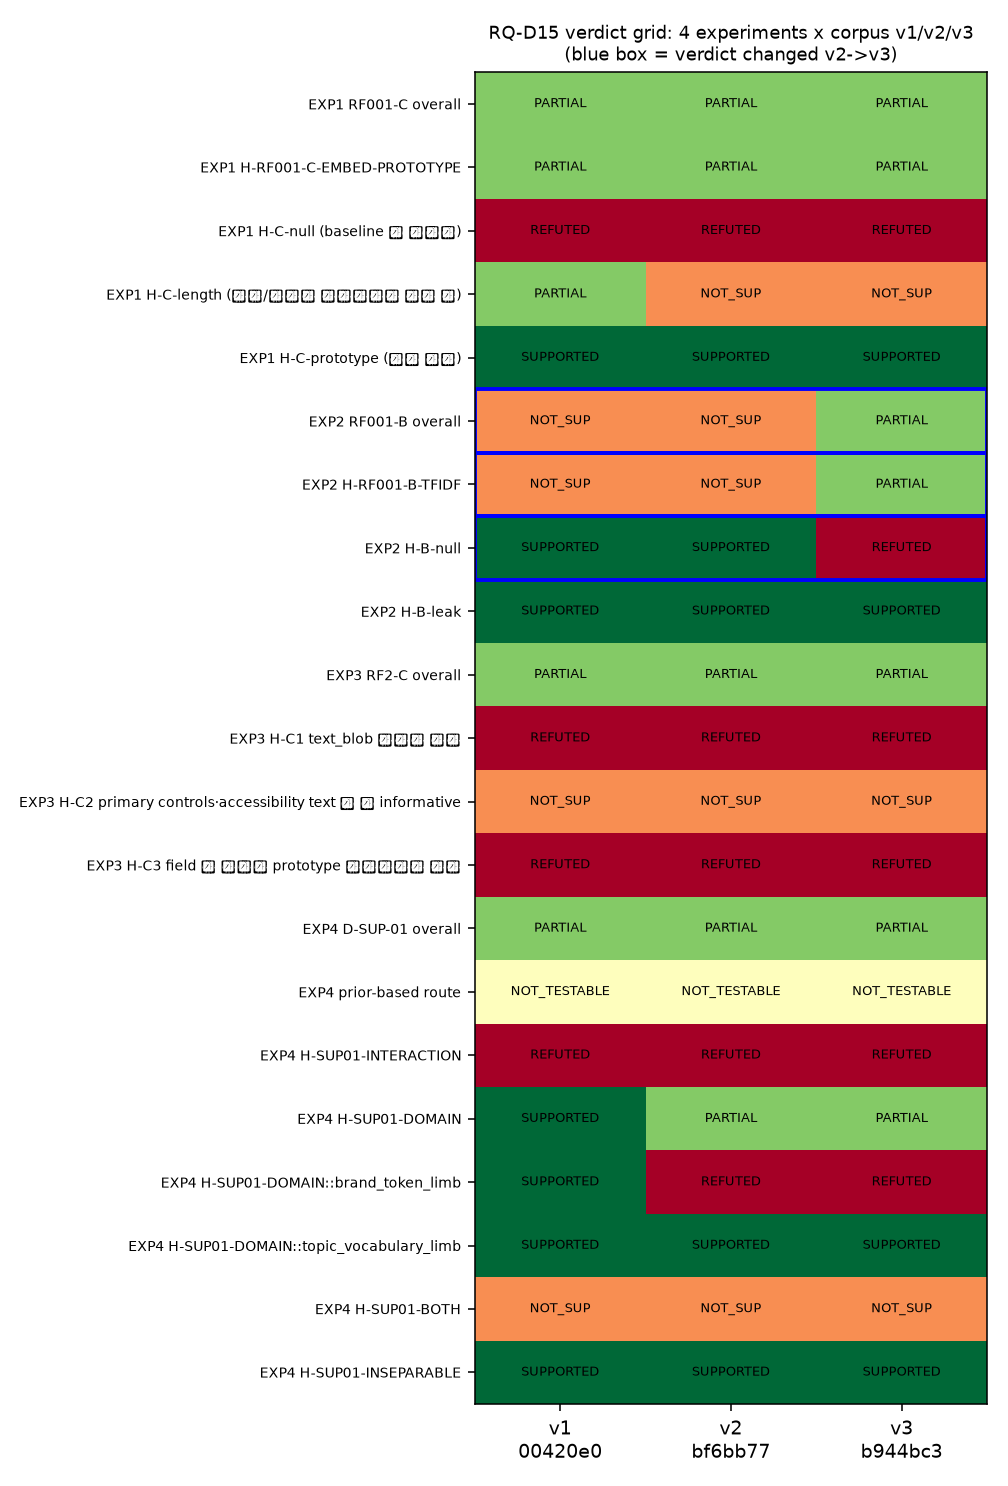

In [4]:
display(Image(filename=doc["figures"]["verdict_grid"]))

## 3. 실험별 수치 비교 (v1 / v2 / v3 병기)

### 3.1 EXP1 — 임베딩 prototype (RF001-C 계열)
frozen SSOT prototype 3세트 × 모델 3종 × `text_blob`. 판정 기준선은 stratified (MC 20000).

In [5]:
e1 = doc["exp1_embedding"]["per_version"]
rows = []
for v in V:
    p = e1[v]["primary"]
    rows.append({"version": v, "verdict": e1[v]["verdict"],
                 "macro_f1": round(p["macro_f1"], 4),
                 "prior_agreement": p["prior_agreement_fraction"],
                 "wilson95": [round(x, 3) for x in p["prior_agreement_wilson95"]],
                 "fold_f1_mean": round(p["fold_macro_f1_30"]["summary"]["mean"], 4),
                 "fold_f1_sd": round(p["fold_macro_f1_30"]["summary"]["std"], 4),
                 "perm_p": p["label_permutation_test"]["macro_f1_p"],
                 "n_classes_pred": p["n_distinct_predicted_classes"],
                 "margin_median": round(p["margin_median"], 5),
                 "n_cfg_beat_strat_p95": e1[v]["prototype_sensitivity"]["global"]["n_configs_beating_stratified_p95"],
                 "proto_f1_range_9cfg": round(e1[v]["prototype_sensitivity"]["global"]["macro_f1_range_all_9_configs"], 4)})
pd.DataFrame(rows).set_index("version")

,verdict,macro_f1,prior_agreement,wilson95,fold_f1_mean,fold_f1_sd,perm_p,n_classes_pred,margin_median,n_cfg_beat_strat_p95,proto_f1_range_9cfg
version,,,,,,,,,,,
v1,PARTIALLY_SUPPORTED,0.4970,37/56,"[0.53, 0.771]",0.4682,0.1096,0.00005,6,0.01900,8,0.2988
v2,PARTIALLY_SUPPORTED,0.5088,38/56,"[0.548, 0.786]",0.4750,0.1142,0.00005,6,0.02143,8,0.3245
v3,PARTIALLY_SUPPORTED,0.5088,38/56,"[0.548, 0.786]",0.4750,0.1142,0.00005,6,0.02143,8,0.3728


In [6]:
# 9 config 격자 (모델 x prototype set) macro F1
cfgk = list(e1["v3"]["configs"])
pd.DataFrame({v: {k: round(e1[v]["configs"][k]["macro_f1"], 4) for k in cfgk} for v in V})

,v1,v2,v3
bge-m3|A_SSOT_DEF,0.4970,0.5088,0.5088
bge-m3|B_USER_BEHAVIOR,0.3549,0.3865,0.3865
bge-m3|C_TERSE_LABEL,0.4633,0.5373,0.5373
e5-small|A_SSOT_DEF,0.4427,0.4577,0.4510
e5-small|B_USER_BEHAVIOR,0.1982,0.2189,0.2189
e5-small|C_TERSE_LABEL,0.3714,0.3808,0.4031
minilm|A_SSOT_DEF,0.4919,0.5433,0.5916
minilm|B_USER_BEHAVIOR,0.4876,0.5083,0.5083
minilm|C_TERSE_LABEL,0.4216,0.4669,0.5168


### 3.2 EXP2 — TF-IDF (RF001-B 계열)
`RepeatedStratifiedKFold(3×10, seed=20260827)` = 30 fold. 판정 근거는 **사전 선언 primary** 와
**E(브랜드-only 대조군)를 제외한 사후 최댓값** 둘 다이며, 기준선은 stratified 다
(majority 대비 lift 는 rigged 이므로 병기만 한다).

In [7]:
e2 = doc["exp2_tfidf"]["per_version"]
rows = []
for v in V:
    j, pr, dl, bl = e2[v]["judgment"], e2[v]["primary_result"], e2[v]["deleak_primary_result"], e2[v]["brand_leak_test"]
    rows.append({"version": v, "verdict": e2[v]["verdict"],
                 "primary_mean": round(pr["summary"]["mean"], 4),
                 "primary_p2_5": round(pr["summary"]["p2_5"], 4),
                 "deleak_mean": round(dl["summary"]["mean"], 4),
                 "best_legit": e2[v]["best_config_post_hoc"]["key"],
                 "best_legit_mean": round(e2[v]["best_config_post_hoc"]["summary"]["mean"], 4),
                 "brandE_best": bl["brand_only_best_key"],
                 "brandE_best_mean": round(bl["brand_only_best_macro_f1"], 4),
                 "stratified_mean": round(j["stratified_baseline_mean"], 4),
                 "primary_sep": j["primary_separates"], "best_legit_sep": j["best_legit_separates"],
                 "brandE_sep": j["brand_only_control_separates"], "deleak_sep": j["deleak_separates"]})
pd.DataFrame(rows).set_index("version")

,verdict,primary_mean,primary_p2_5,deleak_mean,best_legit,best_legit_mean,brandE_best,brandE_best_mean,stratified_mean,primary_sep,best_legit_sep,brandE_sep,deleak_sep
version,,,,,,,,,,,,,
v1,NOT_SUPPORTED,0.2148,0.0892,0.1758,A_blob_full.char_wb.logreg,0.3302,E_brand_only.char_wb.linsvc,0.3629,0.1545,False,False,True,False
v2,NOT_SUPPORTED,0.2298,0.0879,0.1940,A_blob_full.char_wb.logreg,0.3360,E_brand_only.char_wb.linsvc,0.4080,0.1545,False,False,True,False
v3,PARTIALLY_SUPPORTED,0.2299,0.0879,0.1967,A_blob_full.char_wb.logreg,0.3697,E_brand_only.char_wb.linsvc,0.4459,0.1545,False,True,True,False


In [8]:
# 20셀 전체 격자 (fold macro F1 평균). E_* 는 모델 후보가 아니라 leak 상한 대조군이다.
keys = sorted(e2["v3"]["configs"])
pd.DataFrame({v: {k: round(e2[v]["configs"][k]["summary"]["mean"], 4) for k in keys} for v in V})

,v1,v2,v3
A_blob_full.char_wb.linsvc,0.2912,0.3078,0.3451
A_blob_full.char_wb.logreg,0.3302,0.3360,0.3697
A_blob_full.word.linsvc,0.1841,0.2018,0.2018
A_blob_full.word.logreg,0.2148,0.2298,0.2299
B_title_head_nav.char_wb.linsvc,0.2659,0.3083,0.3083
B_title_head_nav.char_wb.logreg,0.2881,0.3046,0.3046
B_title_head_nav.word.linsvc,0.1899,0.2193,0.2193
B_title_head_nav.word.logreg,0.2126,0.2268,0.2268
C_blob_no_url.char_wb.linsvc,0.2586,0.2740,0.3200
C_blob_no_url.char_wb.logreg,0.3050,0.3190,0.3526


### 3.3 EXP3 — field ablation (RF2-C 계열)
**H-C2(접근성 텍스트·primary control 이 더 informative 한가)** 를 v3 에서도 명시적으로 답한다.

In [9]:
e3 = doc["exp3_field_ablation"]["per_version"]
pd.DataFrame({v: e3[v]["headline"] for v in V}).T

,best_representation,best_macro_f1,best_prior_agreement_all56,text_blob_macro_f1,text_blob_prior_agreement_all56,best_control_surface,best_control_macro_f1,best_topic_surface,best_topic_macro_f1,primary_controls_macro_f1,title_macro_f1,field_macro_f1_range,max_prototype_macro_f1_range,stratified_p95_macro_f1
v1,identity,0.515873,0.660714,0.496951,0.660714,buttons,0.303964,identity,0.515873,0.22627,0.434432,0.479007,0.142019,0.221731
v2,title,0.55919,0.607143,0.508777,0.678571,buttons,0.334114,title,0.55919,0.254308,0.55919,0.529634,0.150834,0.221731
v3,title,0.55919,0.607143,0.508777,0.678571,buttons,0.309668,title,0.55919,0.254308,0.55919,0.529634,0.150834,0.221731


In [10]:
reps = list(doc["exp3_field_ablation"]["design"]["representation_fields"])
tab = pd.DataFrame({v: {r: round(e3[v]["grid"][f"{r}|{PP}"]["macro_f1"], 4) for r in reps} for v in V})
tab["delta_v2_v3"] = (tab["v3"] - tab["v2"]).round(4)
tab["family"] = ["control" if r in doc["exp3_field_ablation"]["design"]["control_family"]
                 else ("topic" if r in doc["exp3_field_ablation"]["design"]["topic_family"] else "other")
                 for r in tab.index]
tab.sort_values("v3", ascending=False)

,v1,v2,v3,delta_v2_v3,family
title,0.4344,0.5592,0.5592,0.0000,topic
identity,0.5159,0.5561,0.5561,0.0000,topic
text_blob__ALL,0.4970,0.5088,0.5088,0.0000,other
meta_description,0.4730,0.4964,0.4964,0.0000,topic
structure,0.4374,0.4209,0.4589,0.0380,topic
content_body,0.4166,0.4490,0.4490,0.0000,topic
nav_links,0.3904,0.4378,0.4378,0.0000,topic
headings,0.3805,0.4356,0.4356,0.0000,topic
ssot7_bundle,0.4640,0.4328,0.4328,0.0000,topic
landmarks,0.3920,0.4003,0.4215,0.0212,topic


In [11]:
print("H-C2 판정:")
for v in V:
    print(f"  {v}: {e3[v]['hypotheses']['H-C2 primary controls·accessibility text 가 더 informative']}"
          f"   best_control={e3[v]['headline']['best_control_surface']}"
          f"({e3[v]['headline']['best_control_macro_f1']:.4f})"
          f" vs best_topic={e3[v]['headline']['best_topic_surface']}"
          f"({e3[v]['headline']['best_topic_macro_f1']:.4f})")

H-C2 판정:
  v1: NOT_SUPPORTED   best_control=buttons(0.3040) vs best_topic=identity(0.5159)
  v2: NOT_SUPPORTED   best_control=buttons(0.3341) vs best_topic=title(0.5592)
  v3: NOT_SUPPORTED   best_control=buttons(0.3097) vs best_topic=title(0.5592)


### 3.4 EXP4 — representation ablation (D-SUP-01 계열)
헤드라인은 **prior 를 거치지 않는 지표**다 (representation 간 예측 일치율 + McNemar exact).
prior 기반 경로는 D-FACT-01 전단사 때문에 `NOT_TESTABLE` 이다.

In [12]:
e4 = doc["exp4_representation_ablation"]["per_version"]
rows = []
for v in V:
    E1, E2 = e4[v]["E1_which_surface_drives_FULL"][PP], e4[v]["E2_brand_removal_vs_placebo"][PP]
    rows.append({"version": v, "verdict": e4[v]["verdict"], "n_cc": e4[v]["n_complete_case"],
                 "TOPIC~FULL": E1["topic_reproduces_full_fraction"],
                 "CONTROL~FULL": E1["control_reproduces_full_fraction"],
                 "diff": round(E1["difference_topic_minus_control"], 3),
                 "mcnemar_p": round(E1["mcnemar_exact"]["p_two_sided"], 6),
                 "brand_removal_change": E2["brand_removal_pred_change_fraction"],
                 "placebo_range": f"{E2['placebo_pred_change_min']:.2f}~{E2['placebo_pred_change_max']:.2f}",
                 "brand_within_placebo": E2["brand_within_placebo_range"]})
pd.DataFrame(rows).set_index("version")

,verdict,n_cc,TOPIC~FULL,CONTROL~FULL,diff,mcnemar_p,brand_removal_change,placebo_range,brand_within_placebo
version,,,,,,,,,
v1,PARTIALLY_SUPPORTED,45,36/45,18/45,0.40,0.000277,9/45,0.11~0.13,False
v2,PARTIALLY_SUPPORTED,50,36/50,20/50,0.32,0.002494,8/50,0.14~0.18,True
v3,PARTIALLY_SUPPORTED,50,36/50,20/50,0.32,0.002494,8/50,0.12~0.16,True


In [13]:
pd.DataFrame({v: e4[v]["hypothesis_verdicts_priorfree"] for v in V})

,v1,v2,v3
H-SUP01-INTERACTION,REFUTED,REFUTED,REFUTED
H-SUP01-DOMAIN,SUPPORTED,PARTIALLY_SUPPORTED,PARTIALLY_SUPPORTED
H-SUP01-DOMAIN::brand_token_limb,SUPPORTED,REFUTED,REFUTED
H-SUP01-DOMAIN::topic_vocabulary_limb,SUPPORTED,SUPPORTED,SUPPORTED
H-SUP01-BOTH,NOT_SUPPORTED,NOT_SUPPORTED,NOT_SUPPORTED
H-SUP01-INSEPARABLE,SUPPORTED,SUPPORTED,SUPPORTED


## 4. Google 과 QUERY — 별도 절

v2→v3 에서 Google 의 `text_blob` 토큰이 **118 → 57 (−52%)** 로 줄었다. QUERY 는 **n=4** 뿐이라
target 하나가 recall 을 0.25 단위로 움직인다.

In [14]:
gq = doc["google_and_query"]
print(gq["why"], "\n")
pd.DataFrame({v: {k: gq["target"][v][k] for k in ("blob_tokens", "blob_chars",
                                                 "landmarks_len", "buttons_len")} for v in V})

v2→v3 에서 Google 의 text_blob 토큰이 118→57 (-52%) 로 줄었다. QUERY 는 n=4 뿐이라 한 target 의 예측 변화가 class recall 을 0.25 단위로 움직인다. 별도로 본다. 



,v1,v2,v3
blob_tokens,118,118,57
blob_chars,704,704,297
landmarks_len,200,200,8
buttons_len,232,232,17


In [15]:
for v in V:
    print(f"--- {v} landmarks[:160] ---")
    print(gq["target"][v]["landmarks_preview"][:160])

--- v1 landmarks[:160] ---
#navd{position:absolute;top:0}.KojFAc:focus{outline:none}.xuwOJb{display:none;overflow:hidden;position:fixed;inset:0;z-index:199}.SSH64d{background-color:var(--
--- v2 landmarks[:160] ---
#navd{position:absolute;top:0}.KojFAc:focus{outline:none}.xuwOJb{display:none;overflow:hidden;position:fixed;inset:0;z-index:199}.SSH64d{background-color:var(--
--- v3 landmarks[:160] ---
전체이미지로그인


In [16]:
print("Google 예측 (경로별):")
print(json.dumps({k: val for k, val in gq["prediction_by_experiment"].items()
                  if isinstance(val.get("v2"), str)}, ensure_ascii=False, indent=1))
print("\nv2->v3 에서 바뀐 경로:", gq["google_prediction_changed_v2_to_v3"])
pd.DataFrame(gq["prediction_by_experiment"]["EXP1_all_9_configs"])

Google 예측 (경로별):
{
 "EXP1_embedding_primary": {
  "v1": "QUERY",
  "v2": "QUERY",
  "v3": "QUERY"
 },
 "EXP2_tfidf_oof_majority_primary": {
  "v1": "ITEM_DETAIL",
  "v2": "ITEM_DETAIL",
  "v3": "ITEM_DETAIL"
 }
}

v2->v3 에서 바뀐 경로: {'EXP1_embedding_primary': False, 'EXP2_tfidf_oof_majority_primary': False}


,v1,v2,v3
bge-m3|A_SSOT_DEF,QUERY,QUERY,QUERY
bge-m3|B_USER_BEHAVIOR,QUERY,QUERY,QUERY
bge-m3|C_TERSE_LABEL,QUERY,QUERY,QUERY
e5-small|A_SSOT_DEF,QUERY,QUERY,QUERY
e5-small|B_USER_BEHAVIOR,QUERY,QUERY,QUERY
e5-small|C_TERSE_LABEL,QUERY,QUERY,QUERY
minilm|A_SSOT_DEF,PLACE_LOOKUP,PLACE_LOOKUP,QUERY
minilm|B_USER_BEHAVIOR,QUERY,QUERY,QUERY
minilm|C_TERSE_LABEL,PLACE_LOOKUP,PLACE_LOOKUP,QUERY


In [17]:
qm = gq["query_class_metrics"]
rows = []
for v in V:
    for src, m in qm[v].items():
        rows.append({"version": v, "source": src, "recall": m["recall_fraction"],
                     "recall_wilson95": [round(x, 3) for x in m["recall_wilson95"]],
                     "precision": m["precision_fraction"], "f1": round(m["f1"], 4)})
pd.DataFrame(rows).set_index(["source", "version"])

,,recall,recall_wilson95,precision,f1
source,version,,,,
EXP1_embedding_primary,v1,2/4,"[0.15, 0.85]",2/7,0.3636
EXP2_tfidf_oof_majority,v1,0/4,"[0.0, 0.49]",0/0,0.0000
EXP3_text_blob__ALL,v1,2/4,"[0.15, 0.85]",2/7,0.3636
EXP3_title,v1,2/4,"[0.15, 0.85]",2/2,0.6667
EXP1_embedding_primary,v2,2/4,"[0.15, 0.85]",2/5,0.4444
EXP2_tfidf_oof_majority,v2,0/4,"[0.0, 0.49]",0/0,0.0000
EXP3_text_blob__ALL,v2,2/4,"[0.15, 0.85]",2/5,0.4444
EXP3_title,v2,2/4,"[0.15, 0.85]",2/2,0.6667
EXP1_embedding_primary,v3,2/4,"[0.15, 0.85]",2/5,0.4444


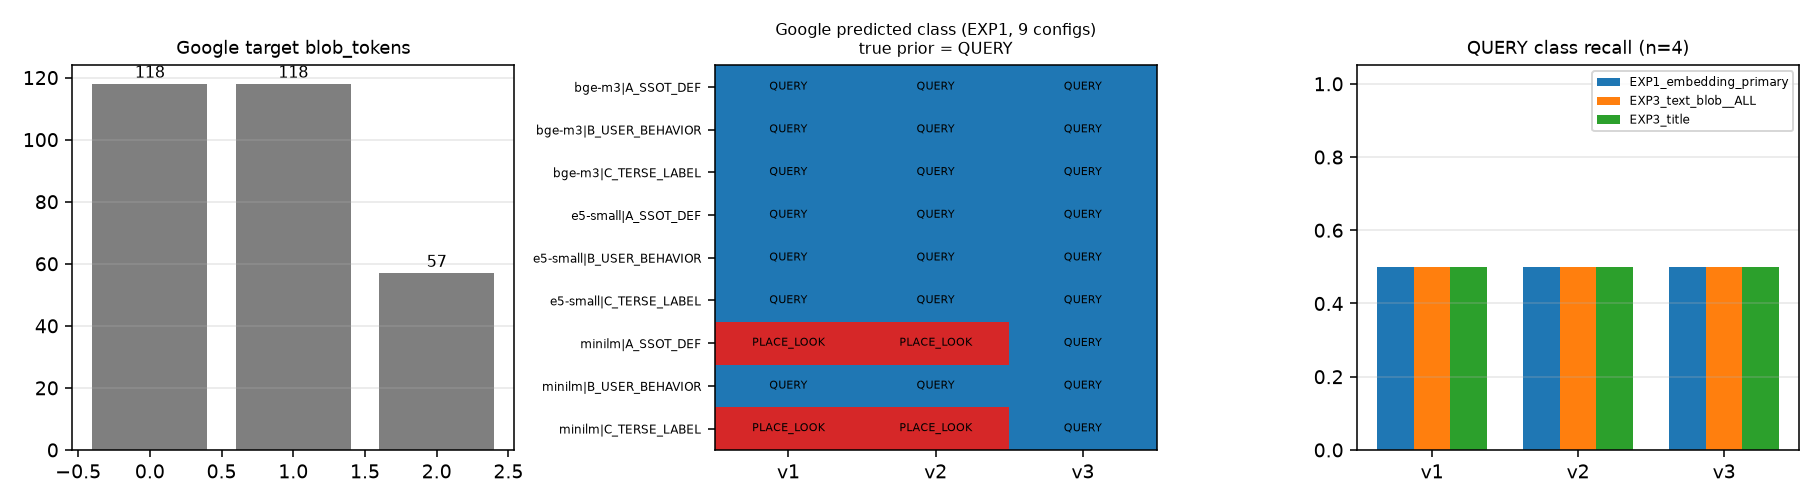

In [18]:
display(Image(filename=doc["figures"]["google_query"]))

## 5. 불확실성 — fold 분포 · permutation null · 버전차 vs 노이즈

zero-shot 실험(EXP1/3/4)은 학습이 없으므로 CV 로 분산을 만들 수 없다. 대신 **같은
`RepeatedStratifiedKFold(3×10)` 의 30개 test fold 위에서 고정 예측을 평가**해 EXP2 와 비교 가능한
fold 분포를 만들고, 라벨 순열 귀무분포(20000회) 와 층내 순열(길이 tertile)을 병기한다.

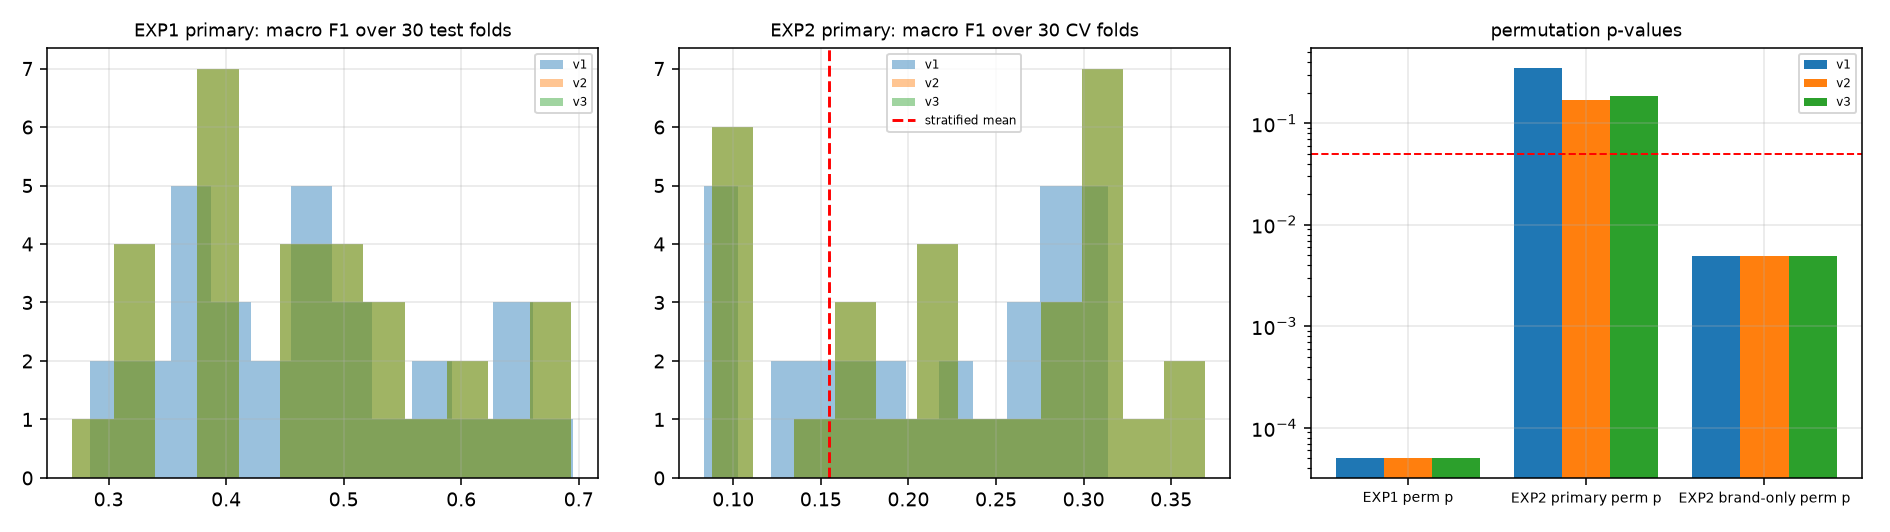

In [19]:
display(Image(filename=doc["figures"]["uncertainty"]))

In [20]:
na = doc["version_delta_vs_noise"]
print(na["why"])
print("max possible prior_agreement shift v2->v3:", round(na["max_possible_prior_agreement_shift_v2_v3"], 4))
rows = []
for k, d in na["per_experiment"].items():
    if "delta_v2_v3" in d:
        rows.append({"quantity": k, "delta_v2_v3": round(d["delta_v2_v3"], 4),
                     "delta_v1_v3": round(d.get("delta_v1_v3", float("nan")), 4),
                     "fold_sd_v3": round(d.get("fold_sd_v3", d.get("fold_macro_f1_sd_v3", float("nan"))), 4),
                     "exceeds_fold_sd": d.get("delta_v2_v3_exceeds_fold_sd"),
                     "n_pred_changed_v2_v3": d.get("n_targets_prediction_changed_v2_v3"),
                     "mcnemar_p_v2_v3": (d.get("mcnemar_correctness_v2_vs_v3") or {}).get("p_two_sided")})
pd.DataFrame(rows).set_index("quantity")

v2→v3 에서 바뀐 target 이 4/56 뿐이므로 prior_agreement 는 원리적으로 최대 4/56=0.0714 만 움직일 수 있다. 지표가 안 움직이는 것도 결과다.
max possible prior_agreement shift v2->v3: 0.0714


,delta_v2_v3,delta_v1_v3,fold_sd_v3,exceeds_fold_sd,n_pred_changed_v2_v3,mcnemar_p_v2_v3
quantity,,,,,,
EXP1_embedding_primary,0.0000,0.0118,0.1142,False,0.0,1.0
EXP2_tfidf_primary,0.0001,0.0152,NaN,False,NaN,NaN
EXP3_title,0.0000,0.1248,0.1133,False,0.0,1.0
EXP3_identity,0.0000,0.0402,0.1287,False,0.0,1.0
EXP3_primary_controls,0.0000,0.0280,0.0837,False,0.0,1.0
EXP3_text_blob__ALL,0.0000,0.0118,0.1142,False,0.0,1.0


## 6. per-class + Wilson CI (EXP1 PRIMARY)

archetype n: ITEM_DETAIL 26 / FINANCIAL 10 / UTILITY 5 / COMMUNICATION 4 / PLACE 4 / QUERY 4 /
CONTENT 3 — **5개가 n≤5**. Wilson CI 없이 읽으면 안 되고, 과해석하지 않는다.

In [21]:
rows = []
for v in V:
    for c, m in doc["exp1_embedding"]["per_version"][v]["primary"]["per_class"].items():
        rows.append({"class": c, "version": v, "n": m["support"], "recall": m["recall_fraction"],
                     "recall_wilson95": [round(x, 3) if x is not None else None
                                         for x in m["recall_wilson95"]],
                     "precision": m["precision_fraction"], "f1": round(m["f1"], 4)})
pd.DataFrame(rows).set_index(["class", "version"])

,,n,recall,recall_wilson95,precision,f1
class,version,,,,,
QUERY,v1,4,2/4,"[0.15, 0.85]",2/7,0.3636
CONTENT_OPEN,v1,3,1/3,"[0.061, 0.792]",1/2,0.4000
ITEM_DETAIL,v1,26,18/26,"[0.5, 0.835]",18/19,0.8000
PLACE_LOOKUP,v1,4,3/4,"[0.301, 0.954]",3/8,0.5000
COMMUNICATION_ENTRY,v1,4,3/4,"[0.301, 0.954]",3/7,0.5455
FINANCIAL_ACTION_ENTRY,v1,10,10/10,"[0.722, 1.0]",10/13,0.8696
UTILITY_ENTRY,v1,5,0/5,"[0.0, 0.434]",0/0,0.0000
QUERY,v2,4,2/4,"[0.15, 0.85]",2/5,0.4444
CONTENT_OPEN,v2,3,1/3,"[0.061, 0.792]",1/2,0.4000


## 7. superseding finding · 반례 · limitation

기존 D 산출물은 **하나도 고치지 않았다.** 판정이 뒤집힌 항목이 있으면 아래 superseding finding 으로만
기록한다.

In [22]:
print("superseding findings:", len(doc["superseding_findings"]))
print(json.dumps(doc["superseding_findings"], ensure_ascii=False, indent=1))
print("\n반례:")
for c in doc["counterexamples"]:
    print(" -", c)
print("\nlimitation:\n", doc["limitation"])
print("\n추가 연구질문:")
for q in doc["further_questions"]:
    print(" -", q)

superseding findings: 6
[
 {
  "affected_row": "EXP1 H-C-length (길이/도메인 어휘밀도를 재는 중)",
  "v1": "PARTIALLY_SUPPORTED",
  "v2": "NOT_SUPPORTED",
  "v3": "NOT_SUPPORTED",
  "supersedes": "기존 D 산출물의 해당 판정은 오염 코퍼스 기준이다. 기존 파일은 고치지 않았고 여기에 superseding finding 으로만 기록한다.",
  "authoritative_version": "v3"
 },
 {
  "affected_row": "EXP2 RF001-B overall",
  "v1": "NOT_SUPPORTED",
  "v2": "NOT_SUPPORTED",
  "v3": "PARTIALLY_SUPPORTED",
  "supersedes": "기존 D 산출물의 해당 판정은 오염 코퍼스 기준이다. 기존 파일은 고치지 않았고 여기에 superseding finding 으로만 기록한다.",
  "authoritative_version": "v3"
 },
 {
  "affected_row": "EXP2 H-RF001-B-TFIDF",
  "v1": "NOT_SUPPORTED",
  "v2": "NOT_SUPPORTED",
  "v3": "PARTIALLY_SUPPORTED",
  "supersedes": "기존 D 산출물의 해당 판정은 오염 코퍼스 기준이다. 기존 파일은 고치지 않았고 여기에 superseding finding 으로만 기록한다.",
  "authoritative_version": "v3"
 },
 {
  "affected_row": "EXP2 H-B-null",
  "v1": "SUPPORTED",
  "v2": "SUPPORTED",
  "v3": "REFUTED",
  "supersedes": "기존 D 산출물의 해당 판정은 오염 코퍼스 기준이다. 기존 파일은 고치지 않았고 여기에 superseding fi

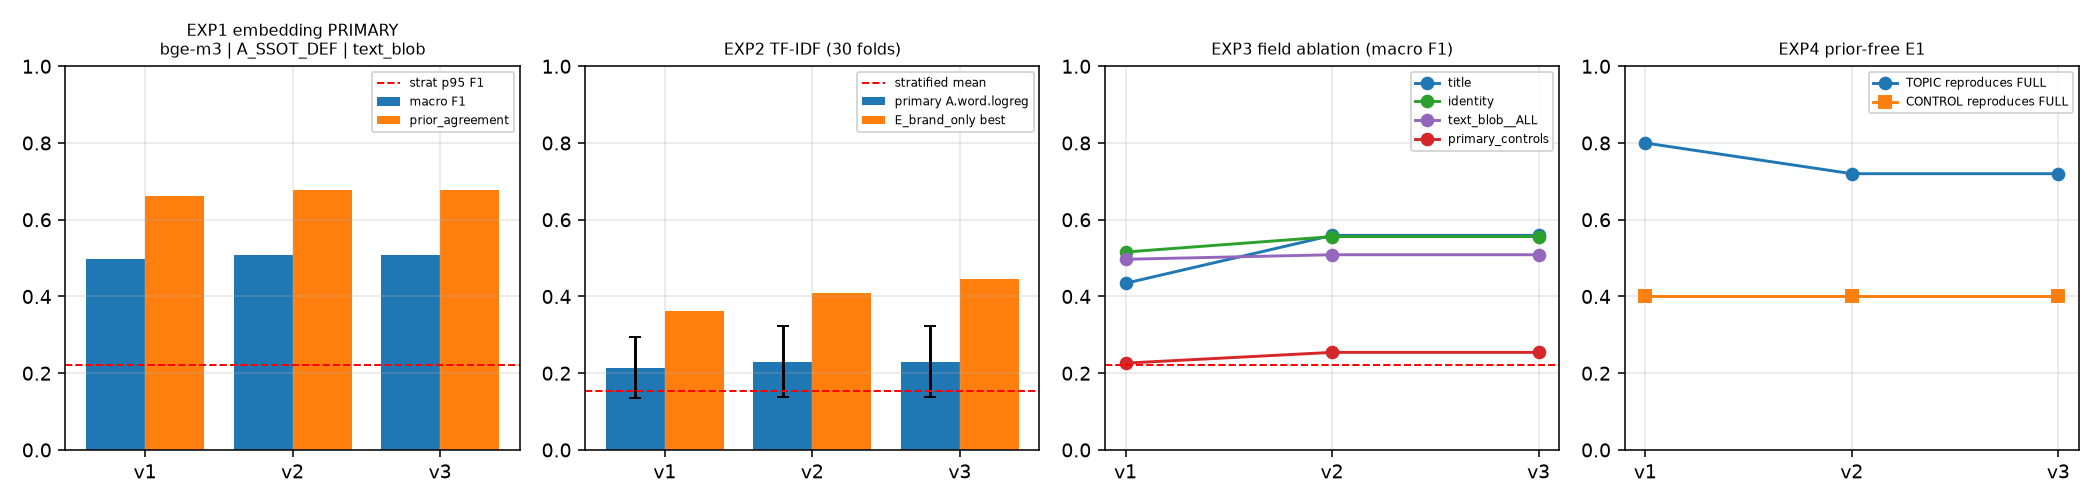

In [23]:
display(Image(filename=doc["figures"]["headline_metrics"]))